In [19]:
# ============================================================
# 1. Imports
# ============================================================
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from contextlib import nullcontext
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

# ============================================================
# 2. Device Setup
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# 3. Load Training Data  (unchanged)
# ============================================================
with open('/content/train.json') as f:
    raw = json.load(f)

def build_story(item):
    return ' '.join([
        item.get('precontext', ''),
        item.get('sentence', ''),
        item.get('ending', '')
    ])

def build_meaning(item):
    return item.get('judged_meaning', '')

items    = list(raw.values())
stories  = [build_story(i)  for i in items]
meanings = [build_meaning(i) for i in items]
labels   = np.array([i['average'] for i in items], dtype=np.float32)
stdevs   = np.array([i['stdev']   for i in items], dtype=np.float32)

# ============================================================
# 4. Tokenization  (unchanged)
# ============================================================
MAX_WORDS = 10000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(stories + meanings)

X_story = pad_sequences(
    tokenizer.texts_to_sequences(stories),
    maxlen=MAX_LEN, padding='post'
)
X_mean = pad_sequences(
    tokenizer.texts_to_sequences(meanings),
    maxlen=MAX_LEN, padding='post'
)

Xs_train, Xs_val, Xm_train, Xm_val, y_train, y_val, s_train, s_val = train_test_split(
    X_story, X_mean, labels, stdevs,
    test_size=0.15, random_state=42
)

# ============================================================
# 5. Load GloVe Embeddings  (unchanged)
# ============================================================
GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

word_index = tokenizer.word_index
num_words  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM), dtype=np.float32)
for word, i in word_index.items():
    if i < num_words and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]

# ============================================================
# 6. Dataset
# ============================================================
class AmbiStoryDataset(Dataset):
    def __init__(self, X_story, X_mean, labels, stdevs):
        self.X_story = torch.tensor(X_story, dtype=torch.long)
        self.X_mean  = torch.tensor(X_mean,  dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
        self.stdevs  = torch.tensor(stdevs,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.X_story[idx],
            self.X_mean[idx],
            self.labels[idx],
            self.stdevs[idx]
        )

train_dataset = AmbiStoryDataset(Xs_train, Xm_train, y_train, s_train)
val_dataset   = AmbiStoryDataset(Xs_val,   Xm_val,   y_val,   s_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)

# ============================================================
# 7. Encoder (BiSimpleRNN — no attention, GloVe trainable)
# ============================================================
class BiRNNEncoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )                                           # GloVe weights, trainable

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=rnn_units,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)                       # (B, L, E)
        x = self.dropout(x)
        out, _ = self.rnn(x)                        # (B, L, 2*rnn_units)
        return out.mean(dim=1)                      # (B, 2*rnn_units)

# ============================================================
# 8. Dual-Encoder Model  (unchanged from prior versions)
# ============================================================
class DualEncoderModel(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units=128, num_layers=1, dropout=0.3,
                 dense_units=128):
        super().__init__()

        encoder_args = (num_words, embed_dim, embedding_matrix,
                        rnn_units, num_layers, dropout)

        self.story_encoder   = BiRNNEncoder(*encoder_args)
        self.meaning_encoder = BiRNNEncoder(*encoder_args)

        combined_dim = rnn_units * 2 * 3            # story + meaning + |diff|

        self.head = nn.Sequential(
            nn.Linear(combined_dim, dense_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dense_units, 1)
        )

    def forward(self, story, meaning):
        sv       = self.story_encoder(story)        # (B, 2*H)
        mv       = self.meaning_encoder(meaning)    # (B, 2*H)
        diff     = torch.abs(sv - mv)
        combined = torch.cat([sv, mv, diff], dim=1) # (B, 6*H)
        return self.head(combined).squeeze(1)       # (B,)

# ============================================================
# 9. Loss Functions
# ============================================================
mse_loss_fn = nn.MSELoss()                          # regression anchor

def pairwise_ranking_loss(preds, labels, margin=1.0):
    """
    Margin-based ranking loss over all pairs in a batch.

    For every (i, j) pair where label_i > label_j the model is
    penalised if pred_i is not sufficiently larger than pred_j:

        L = mean( max(0, margin - (label_i - label_j) * (pred_i - pred_j)) )
              for all i != j

    Vectorised implementation — no Python loops over pairs.

    Args:
        preds  : (B,) predicted scores
        labels : (B,) ground-truth scores
        margin : minimum required score gap (default 1.0)

    Returns:
        scalar loss tensor
    """
    # Outer differences: diff_ij = val_i - val_j  →  shape (B, B)
    label_diff = labels.unsqueeze(1) - labels.unsqueeze(0)   # (B, B)
    pred_diff  = preds.unsqueeze(1)  - preds.unsqueeze(0)    # (B, B)

    # Only penalise pairs where labels are meaningfully different
    # (avoids noisy signal from near-identical scores)
    pair_mask = label_diff.abs() > 0.0                        # (B, B)

    # Core ranking loss: max(0, margin - sign_agreement)
    loss_matrix = torch.clamp(
        margin - label_diff * pred_diff,
        min=0.0
    )                                                          # (B, B)

    # Average only over valid (i != j) pairs
    loss = (loss_matrix * pair_mask).sum() / pair_mask.sum().clamp(min=1)
    return loss


def combined_loss(preds, labels, alpha=0.5, margin=1.0):
    """
    Final training objective:

        L = alpha * MSE  +  (1 - alpha) * RankingLoss

    MSE anchors absolute score accuracy.
    RankingLoss pushes the model to preserve Spearman ordering.

    alpha=0.5 gives equal weight — tune toward 0.3/0.7 if
    Spearman vs MAE trade-off needs adjusting.
    """
    mse  = mse_loss_fn(preds, labels)
    rank = pairwise_ranking_loss(preds, labels, margin=margin)
    return alpha * mse + (1 - alpha) * rank

# ============================================================
# 10. Training Loop
# ============================================================
def get_amp_autocast(device):
    if device.type != 'cuda':
        return nullcontext()
    if hasattr(torch, 'autocast'):
        return torch.autocast(device_type='cuda', dtype=torch.float16, enabled=True)
    return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)


def get_grad_scaler(device):
    amp_enabled = (device.type == 'cuda')
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler(device.type, enabled=amp_enabled)
    return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def train_one_epoch(model, loader, optimizer, scaler,
                    alpha=0.5, margin=1.0):
    model.train()
    total_loss = 0.0

    for story, meaning, label, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_amp_autocast(device):
            preds = model(story, meaning)
            loss  = combined_loss(preds, label, alpha=alpha, margin=margin)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader, alpha=0.5, margin=1.0):
    model.eval()
    total_loss = 0.0

    for story, meaning, label, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)

        preds      = model(story, meaning)
        total_loss += combined_loss(preds, label, alpha=alpha, margin=margin).item()

    return total_loss / len(loader)

# ============================================================
# 11. Instantiate Model, Optimizer, Scheduler
# ============================================================
model = DualEncoderModel(
    num_words=num_words,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    rnn_units=128,
    num_layers=1,
    dropout=0.3,
    dense_units=128
).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
# lr=5e-4 — ranking loss gradients can be large due to O(B^2) pair accumulation
# weight_decay provides L2 regularisation

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)
scaler = get_grad_scaler(device)

# ============================================================
# 12. Run Training with Early Stopping
# ============================================================
EPOCHS        = 30
PATIENCE      = 5
ALPHA         = 0.5                                 # MSE vs Ranking balance
MARGIN        = 1.0                                 # ranking margin

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler,
                                 alpha=ALPHA, margin=MARGIN)
    val_loss   = evaluate_epoch(model, val_loader,
                                alpha=ALPHA, margin=MARGIN)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

# ============================================================
# 13. Evaluation (SemEval Metrics — unchanged)
# ============================================================
@torch.no_grad()
def evaluate(model, Xs, Xm, y=None, s=None, compute_metrics=True):
    model.eval()
    if y is None:
        y = np.zeros(len(Xs), dtype=np.float32)
    if s is None:
        s = np.ones(len(Xs), dtype=np.float32)

    ds     = AmbiStoryDataset(Xs, Xm, y, s)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        pin_memory=(device.type == 'cuda'))

    all_preds = []
    for story, meaning, _, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        preds   = model(story, meaning)
        all_preds.append(preds.cpu().numpy())

    preds = np.clip(np.concatenate(all_preds), 1, 5)
    if compute_metrics:
        s = np.maximum(s, 1.0)

        sp = spearmanr(y, preds).correlation
        print("Spearman r           :", sp)
        print("Accuracy within std  :", np.mean(np.abs(preds - y) <= s))
    return preds

print("\n── Validation Results ──")
val_preds = evaluate(model, Xs_val, Xm_val, y_val, s_val)

# ============================================================
# 14. Predict on Test Set
# ============================================================
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items = list(test_raw.values())
test_story = pad_sequences(
    tokenizer.texts_to_sequences([build_story(i)  for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)
test_mean = pad_sequences(
    tokenizer.texts_to_sequences([build_meaning(i) for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)

dummy_labels = np.ones(len(test_items), dtype=np.float32)
dummy_stdevs = np.ones(len(test_items), dtype=np.float32)

test_preds = evaluate(
    model,
    test_story,
    test_mean,
    dummy_labels,
    dummy_stdevs,
    compute_metrics=False
)

print("\nSample Test Predictions:")
for i in range(min(10, len(test_preds))):
    print(f"Sample {i+1}: {test_preds[i]:.3f}")


Using device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB
Epoch 01 | train_loss: 2.0866 | val_loss: 1.2552
Epoch 02 | train_loss: 1.2995 | val_loss: 1.2500
Epoch 03 | train_loss: 1.2837 | val_loss: 1.1883
Epoch 04 | train_loss: 1.2875 | val_loss: 1.4167
Epoch 05 | train_loss: 1.3171 | val_loss: 1.2320
Epoch 06 | train_loss: 1.2718 | val_loss: 1.2678
Epoch 07 | train_loss: 1.2803 | val_loss: 1.2465
Epoch 08 | train_loss: 1.2560 | val_loss: 1.2248
Early stopping at epoch 8

── Validation Results ──
Spearman r           : 0.17408808622325442
Accuracy within std  : 0.5409356725146199

Sample Test Predictions:
Sample 1: 2.927
Sample 2: 3.259
Sample 3: 2.938
Sample 4: 3.270
Sample 5: 2.869
Sample 6: 3.201
Sample 7: 2.982
Sample 8: 3.313
Sample 9: 2.934
Sample 10: 3.265


Spearman r           : 0.17408808622325442
Accuracy within std  : 0.5409356725146199


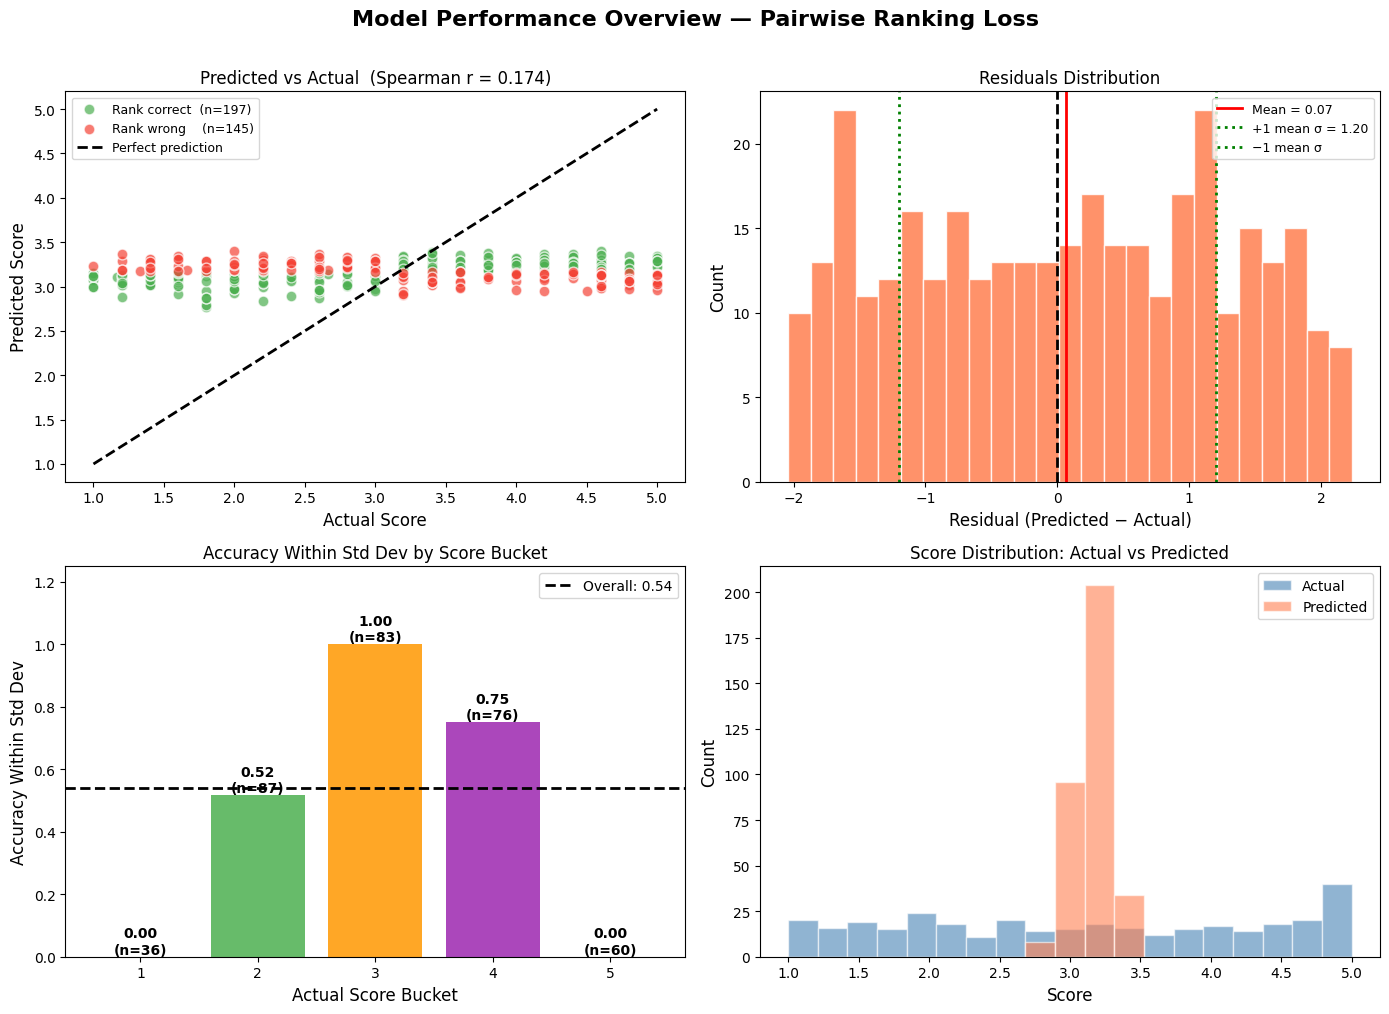

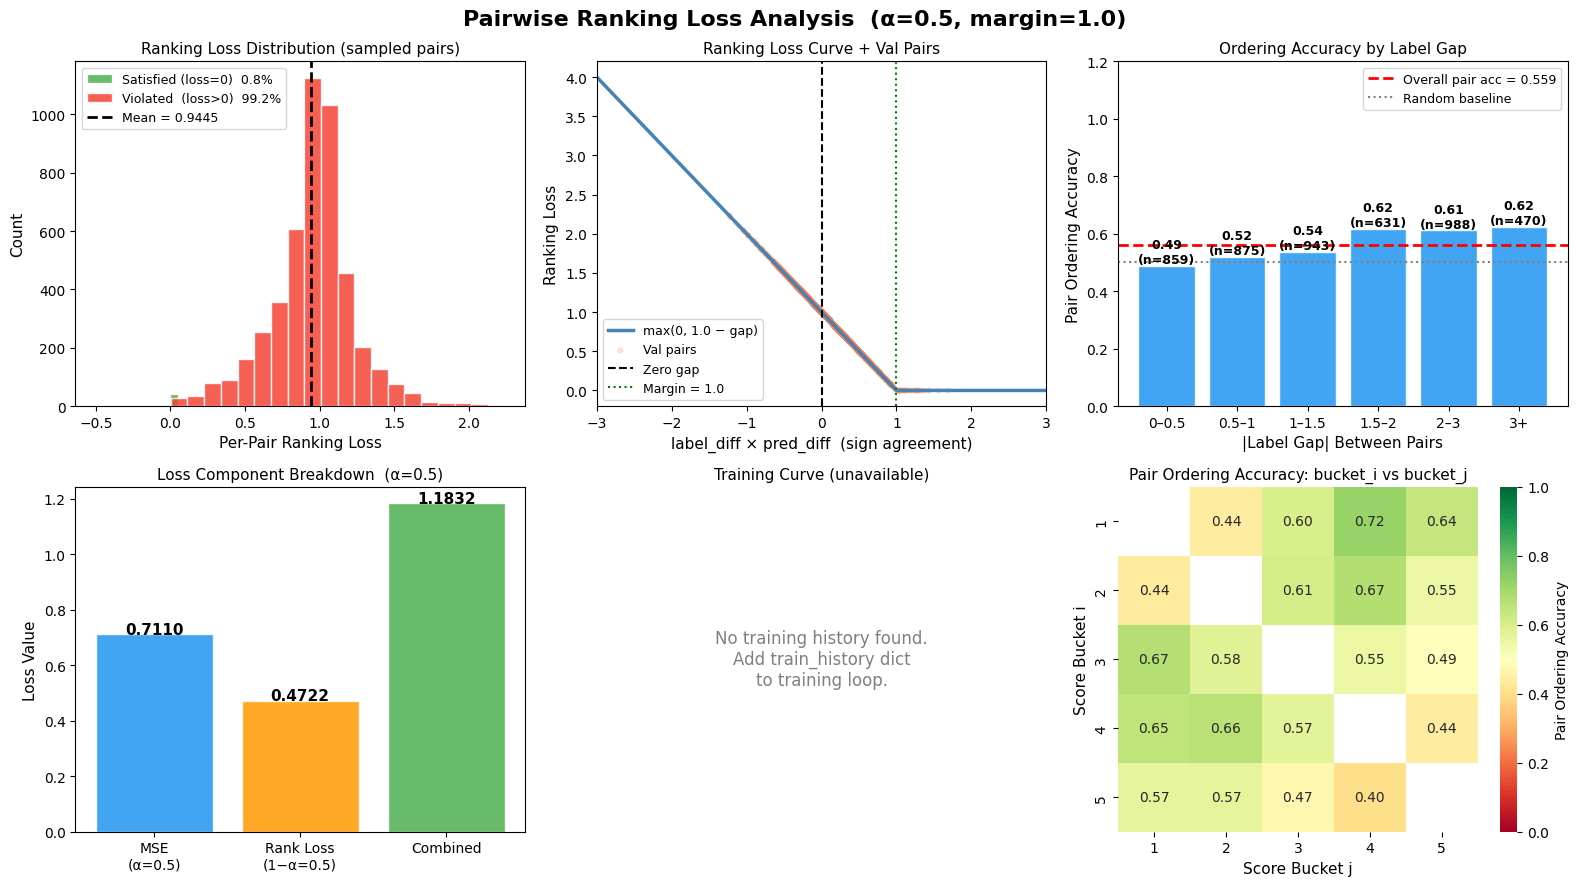

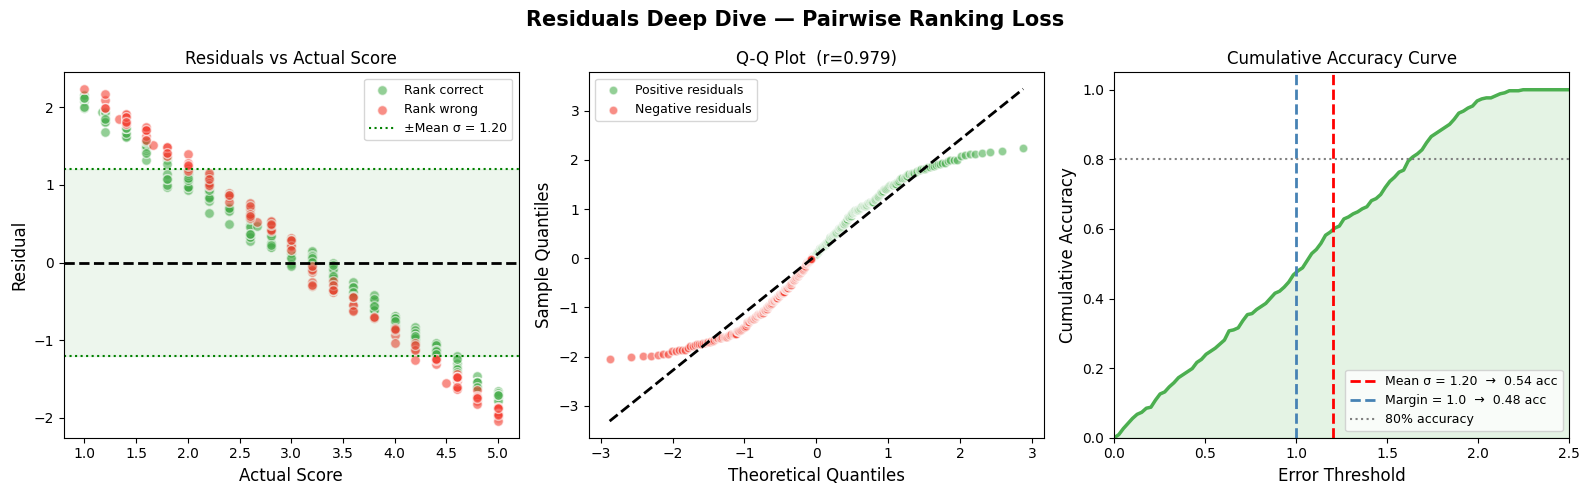

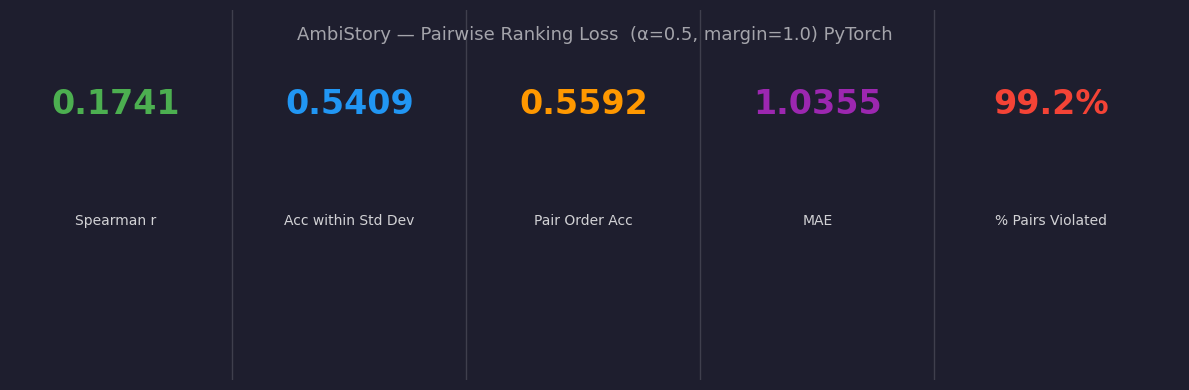


✓ Saved:
  /content/performance_overview.png
  /content/ranking_loss_analysis.png
  /content/residuals_deep_dive.png
  /content/summary_card.png


In [20]:
# ============================================================
# Visualization — Pairwise Ranking Loss (PyTorch)
# Run AFTER training. Requires: model, Xs_val, Xm_val, y_val, s_val
#                               train_history (optional)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import spearmanr

ALPHA  = 0.5   # must match combined_loss(alpha=...) used in training
MARGIN = 1.0   # must match pairwise_ranking_loss(margin=...) used in training

# ── Collect val predictions ────────────────────────────────────────────────
val_preds = evaluate(model, Xs_val, Xm_val, y_val, s_val)   # clipped [1,5]
stdevs    = np.maximum(s_val, 1.0)
residuals = val_preds - y_val
abs_res   = np.abs(residuals)
within    = abs_res <= stdevs
spear     = spearmanr(y_val, val_preds).correlation
mae_val   = abs_res.mean()
mse_val   = np.mean(residuals**2)

# ── Rank-order analysis ────────────────────────────────────────────────────
# Sort both arrays by actual label — used in ordering panels
sort_idx       = np.argsort(y_val)
y_sorted       = y_val[sort_idx]
pred_sorted    = val_preds[sort_idx]

# Per-pair ordering correctness (vectorised, sampled for speed)
rng      = np.random.default_rng(42)
n        = len(y_val)
n_pairs  = min(5000, n * (n - 1) // 2)           # cap for large datasets
idx_i    = rng.integers(0, n, n_pairs)
idx_j    = rng.integers(0, n, n_pairs)
valid    = idx_i != idx_j
idx_i, idx_j = idx_i[valid], idx_j[valid]

label_diff_pairs = y_val[idx_i]   - y_val[idx_j]
pred_diff_pairs  = val_preds[idx_i] - val_preds[idx_j]
sign_agree       = np.sign(label_diff_pairs) == np.sign(pred_diff_pairs)
nontrivial       = np.abs(label_diff_pairs) > 0.0
pair_acc         = sign_agree[nontrivial].mean()   # % of pairs correctly ordered

# Per-pair ranking loss values (for distribution analysis)
pair_rank_loss = np.maximum(
    0.0,
    MARGIN - label_diff_pairs * pred_diff_pairs
)
pair_rank_loss_nontrivial = pair_rank_loss[nontrivial]

has_history = 'train_history' in globals()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Model Performance Overview
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Overview — Pairwise Ranking Loss',
             fontsize=16, fontweight='bold', y=1.01)

# ── 1. Predicted vs Actual (coloured by ordering correctness) ─────────────
ax = axes[0, 0]
# Colour each point by whether its rank vs mean is preserved
above_mean_actual = y_val    >= y_val.mean()
above_mean_pred   = val_preds >= val_preds.mean()
rank_correct      = above_mean_actual == above_mean_pred

ax.scatter(y_val[rank_correct],  val_preds[rank_correct],
           alpha=0.7, color='#4CAF50', edgecolors='white', s=60,
           label=f'Rank correct  (n={rank_correct.sum()})')
ax.scatter(y_val[~rank_correct], val_preds[~rank_correct],
           alpha=0.7, color='#F44336', edgecolors='white', s=60,
           label=f'Rank wrong    (n={(~rank_correct).sum()})')
ax.plot([1, 5], [1, 5], 'k--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score',    fontsize=12)
ax.set_ylabel('Predicted Score', fontsize=12)
ax.set_title(f'Predicted vs Actual  (Spearman r = {spear:.3f})', fontsize=12)
ax.legend(fontsize=9); ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)

# ── 2. Residuals Distribution ─────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0,                color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red',   linestyle='-',  lw=2,
           label=f'Mean = {residuals.mean():.2f}')
ax.axvline( stdevs.mean(),   color='green', linestyle=':',  lw=2,
           label=f'+1 mean σ = {stdevs.mean():.2f}')
ax.axvline(-stdevs.mean(),   color='green', linestyle=':',  lw=2,
           label=f'−1 mean σ')
ax.set_xlabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_ylabel('Count',                         fontsize=12)
ax.set_title('Residuals Distribution',         fontsize=12)
ax.legend(fontsize=9)

# ── 3. Accuracy Within Std Dev per Score Bucket ───────────────────────────
ax = axes[1, 0]
buckets    = [1, 2, 3, 4, 5]
bucket_acc = []
bucket_n   = []
for b in buckets:
    mask = (np.round(y_val) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)
    bucket_n.append(mask.sum())

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars   = ax.bar([str(b) for b in buckets], bucket_acc,
                color=colors, alpha=0.85)
ax.axhline(within.mean(), color='black', linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')
for bar, val, n in zip(bars, bucket_acc, bucket_n):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Actual Score Bucket',     fontsize=12)
ax.set_ylabel('Accuracy Within Std Dev', fontsize=12)
ax.set_title('Accuracy Within Std Dev by Score Bucket', fontsize=12)
ax.set_ylim(0, 1.25); ax.legend()

# ── 4. Score Distribution: Actual vs Predicted ────────────────────────────
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val,     bins=bins, alpha=0.6, color='steelblue',
        label='Actual',    edgecolor='white')
ax.hist(val_preds, bins=bins, alpha=0.6, color='coral',
        label='Predicted', edgecolor='white')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Distribution: Actual vs Predicted', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/content/performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Ranking Loss Analysis
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Pairwise Ranking Loss Analysis  (α={ALPHA}, margin={MARGIN})',
             fontsize=16, fontweight='bold')

# ── 1. Per-Pair Ranking Loss Distribution ─────────────────────────────────
ax = axes[0, 0]
violated  = pair_rank_loss_nontrivial > 0
satisfied = ~violated
ax.hist(pair_rank_loss_nontrivial[satisfied], bins=20, color='#4CAF50',
        edgecolor='white', alpha=0.85,
        label=f'Satisfied (loss=0)  {satisfied.mean()*100:.1f}%')
ax.hist(pair_rank_loss_nontrivial[violated],  bins=20, color='#F44336',
        edgecolor='white', alpha=0.85,
        label=f'Violated  (loss>0)  {violated.mean()*100:.1f}%')
ax.axvline(pair_rank_loss_nontrivial.mean(), color='black', lw=2,
           linestyle='--', label=f'Mean = {pair_rank_loss_nontrivial.mean():.4f}')
ax.set_xlabel('Per-Pair Ranking Loss',  fontsize=11)
ax.set_ylabel('Count',                  fontsize=11)
ax.set_title('Ranking Loss Distribution (sampled pairs)', fontsize=11)
ax.legend(fontsize=9)

# ── 2. Rank Loss Curve with sample overlay ────────────────────────────────
ax = axes[0, 1]
gap_range  = np.linspace(-3, 3, 300)
rank_curve = np.maximum(0, MARGIN - gap_range)
ax.plot(gap_range, rank_curve, color='steelblue', lw=2.5,
        label=f'max(0, {MARGIN} − gap)')
ax.scatter(label_diff_pairs[nontrivial] * pred_diff_pairs[nontrivial],
           pair_rank_loss_nontrivial,
           alpha=0.2, color='coral', s=10, label='Val pairs')
ax.axvline(0,      color='black', lw=1.5, linestyle='--', label='Zero gap')
ax.axvline(MARGIN, color='green', lw=1.5, linestyle=':',
           label=f'Margin = {MARGIN}')
ax.set_xlabel('label_diff × pred_diff  (sign agreement)',  fontsize=11)
ax.set_ylabel('Ranking Loss',                              fontsize=11)
ax.set_title('Ranking Loss Curve + Val Pairs', fontsize=11)
ax.set_xlim(-3, 3); ax.legend(fontsize=9)

# ── 3. Pair Ordering Accuracy by Label Gap Size ───────────────────────────
ax = axes[0, 2]
gap_abs    = np.abs(label_diff_pairs[nontrivial])
gap_bins   = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
bin_labels = ['0–0.5','0.5–1','1–1.5','1.5–2','2–3','3+']
bin_acc    = []
bin_counts = []
for lo, hi in zip(gap_bins[:-1], gap_bins[1:]):
    m = (gap_abs >= lo) & (gap_abs < hi)
    bin_acc.append(sign_agree[nontrivial][m].mean() if m.sum() > 0 else 0)
    bin_counts.append(m.sum())

bars = ax.bar(bin_labels, bin_acc, color='#2196F3', alpha=0.85, edgecolor='white')
ax.axhline(pair_acc, color='red', lw=2, linestyle='--',
           label=f'Overall pair acc = {pair_acc:.3f}')
ax.axhline(0.5, color='gray', lw=1.5, linestyle=':', label='Random baseline')
for bar, val, n in zip(bars, bin_acc, bin_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}\n(n={n})', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('|Label Gap| Between Pairs', fontsize=11)
ax.set_ylabel('Pair Ordering Accuracy',    fontsize=11)
ax.set_title('Ordering Accuracy by Label Gap', fontsize=11)
ax.set_ylim(0, 1.2); ax.legend(fontsize=9)

# ── 4. MSE vs Ranking vs Combined Loss breakdown ──────────────────────────
ax = axes[1, 0]
mse_component  = mse_val
rank_component = pair_rank_loss_nontrivial.mean()
combined       = ALPHA * mse_component + (1 - ALPHA) * rank_component

metric_names = [f'MSE\n(α={ALPHA})', f'Rank Loss\n(1−α={1-ALPHA})', 'Combined']
metric_vals  = [ALPHA * mse_component, (1 - ALPHA) * rank_component, combined]
bar_colors   = ['#2196F3', '#FF9800', '#4CAF50']

bars = ax.bar(metric_names, metric_vals,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Loss Value', fontsize=11)
ax.set_title(f'Loss Component Breakdown  (α={ALPHA})', fontsize=11)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# ── 5. Training Curve ─────────────────────────────────────────────────────
ax = axes[1, 1]
if has_history:
    epochs_range = range(1, len(train_history['train_loss']) + 1)
    ax.plot(epochs_range, train_history['train_loss'],
            color='steelblue', lw=2, label='Train Loss')
    ax.plot(epochs_range, train_history['val_loss'],
            color='coral',     lw=2, linestyle='--', label='Val Loss')
    best_ep = int(np.argmin(train_history['val_loss'])) + 1
    best_vl = min(train_history['val_loss'])
    ax.axvline(best_ep, color='green', lw=1.5, linestyle=':',
               label=f'Best epoch={best_ep}  loss={best_vl:.4f}')
    ax.set_xlabel('Epoch',  fontsize=11)
    ax.set_ylabel('Loss',   fontsize=11)
    ax.set_title('Training & Validation Loss (Combined)', fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5,
            'No training history found.\nAdd train_history dict\nto training loop.',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Training Curve (unavailable)', fontsize=11)
    ax.axis('off')

# ── 6. Pair Ordering Accuracy Heatmap (bucket_i × bucket_j) ──────────────
ax = axes[1, 2]
buckets      = [1, 2, 3, 4, 5]
heatmap_data = np.full((len(buckets), len(buckets)), np.nan)
for bi, b_i in enumerate(buckets):
    for bj, b_j in enumerate(buckets):
        if b_i == b_j:
            continue
        mi = np.round(y_val[idx_i[nontrivial]]) == b_i
        mj = np.round(y_val[idx_j[nontrivial]]) == b_j
        m  = mi & mj
        if m.sum() > 0:
            heatmap_data[bi, bj] = sign_agree[nontrivial][m].mean()

sns.heatmap(heatmap_data, ax=ax,
            xticklabels=buckets, yticklabels=buckets,
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Pair Ordering Accuracy'})
ax.set_xlabel('Score Bucket j', fontsize=11)
ax.set_ylabel('Score Bucket i', fontsize=11)
ax.set_title('Pair Ordering Accuracy: bucket_i vs bucket_j', fontsize=11)

plt.tight_layout()
plt.savefig('/content/ranking_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Residuals Deep Dive
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residuals Deep Dive — Pairwise Ranking Loss',
             fontsize=15, fontweight='bold')

# ── 1. Residuals vs Actual Score (coloured by rank correctness) ───────────
ax = axes[0]
ax.scatter(y_val[rank_correct],  residuals[rank_correct],
           color='#4CAF50', alpha=0.6, s=50, edgecolors='white',
           label='Rank correct')
ax.scatter(y_val[~rank_correct], residuals[~rank_correct],
           color='#F44336', alpha=0.6, s=50, edgecolors='white',
           label='Rank wrong')
ax.axhline(0,             color='black', lw=2,   linestyle='--')
ax.axhline( stdevs.mean(), color='green', lw=1.5, linestyle=':',
            label=f'±Mean σ = {stdevs.mean():.2f}')
ax.axhline(-stdevs.mean(), color='green', lw=1.5, linestyle=':')
ax.fill_between([0.8, 5.2], -stdevs.mean(), stdevs.mean(),
                alpha=0.07, color='green')
ax.set_xlabel('Actual Score',             fontsize=12)
ax.set_ylabel('Residual',                 fontsize=12)
ax.set_title('Residuals vs Actual Score', fontsize=12)
ax.set_xlim(0.8, 5.2); ax.legend(fontsize=9)

# ── 2. Q-Q Plot of Residuals ──────────────────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
osr_arr = np.array(osr)
ax.scatter(np.array(osm)[osr_arr >= 0],  osr_arr[osr_arr >= 0],
           color='#4CAF50', alpha=0.6, s=40, edgecolors='white',
           label='Positive residuals')
ax.scatter(np.array(osm)[osr_arr <  0],  osr_arr[osr_arr <  0],
           color='#F44336', alpha=0.6, s=40, edgecolors='white',
           label='Negative residuals')
ax.plot(osm, slope * np.array(osm) + intercept, 'k--', lw=2)
ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles',      fontsize=12)
ax.set_title(f'Q-Q Plot  (r={r:.3f})',  fontsize=12)
ax.legend(fontsize=9)

# ── 3. Cumulative Accuracy Curve ──────────────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 2.5, 100)
cum_acc    = [np.mean(abs_res <= t) for t in thresholds]
ax.plot(thresholds, cum_acc, color='#4CAF50', lw=2.5)
ax.axvline(stdevs.mean(), color='red',   lw=2,   linestyle='--',
           label=f'Mean σ = {stdevs.mean():.2f}  →  {within.mean():.2f} acc')
ax.axvline(MARGIN,        color='steelblue', lw=2, linestyle='--',
           label=f'Margin = {MARGIN}  →  {np.mean(abs_res <= MARGIN):.2f} acc')
ax.axhline(0.8, color='gray', lw=1.5, linestyle=':', label='80% accuracy')
ax.fill_between(thresholds, cum_acc, alpha=0.15, color='#4CAF50')
ax.set_xlabel('Error Threshold',          fontsize=12)
ax.set_ylabel('Cumulative Accuracy',      fontsize=12)
ax.set_title('Cumulative Accuracy Curve', fontsize=12)
ax.set_xlim(0, 2.5); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/residuals_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Summary Card
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 4))
fig.patch.set_facecolor('#1E1E2E')
ax  = fig.add_subplot(111)
ax.set_facecolor('#1E1E2E'); ax.axis('off')

pct_violated = violated.mean() * 100
metrics = [
    ('Spearman r',         f'{spear:.4f}',          '#4CAF50'),
    ('Acc within Std Dev', f'{within.mean():.4f}',  '#2196F3'),
    ('Pair Order Acc',     f'{pair_acc:.4f}',        '#FF9800'),
    ('MAE',                f'{mae_val:.4f}',         '#9C27B0'),
    ('% Pairs Violated',   f'{pct_violated:.1f}%',   '#F44336'),
]

for i, (label, value, color) in enumerate(metrics):
    x = 0.09 + i * 0.20
    ax.text(x, 0.72, value, transform=ax.transAxes,
            fontsize=24, fontweight='bold', color=color, ha='center')
    ax.text(x, 0.42, label, transform=ax.transAxes,
            fontsize=10, color='white', ha='center', alpha=0.8)
    if i < len(metrics) - 1:
        ax.axvline(x + 0.10, color='white', alpha=0.15, lw=1)

ax.text(0.5, 0.92,
        f'AmbiStory — Pairwise Ranking Loss  (α={ALPHA}, margin={MARGIN}) PyTorch',
        transform=ax.transAxes, fontsize=13, color='white',
        ha='center', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/summary_card.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\n✓ Saved:")
print("  /content/performance_overview.png")
print("  /content/ranking_loss_analysis.png")
print("  /content/residuals_deep_dive.png")
print("  /content/summary_card.png")